<a href="https://colab.research.google.com/github/dididi0913/deeplearningstd/blob/main/%ED%98%BC%EA%B3%B5%EB%A8%B8_ch4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4-1 로지스틱 회귀

In [2]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


## knn 최근접

In [3]:
print(pd.unique(fish['Species']))

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [11]:
fish_input = fish[['Weight', 'Length', 'Diagonal','Height', 'Width']].to_numpy()

In [12]:
print(fish_input[:5])

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [13]:
fish_target = fish['Species'].to_numpy()

In [15]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state = 42)

In [16]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors = 3)
kn.fit(train_scaled, train_target)
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [18]:
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


다중클래스

In [19]:
print(kn.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [20]:
import numpy as np
proba = kn.predict_proba(test_scaled[:5]) # 클래스별 확률 값 반환
print(np.round(proba, decimals=4)) #round 함수는 기본적으로 소수점 첫째 자리에서 반올림, decimals로 자릿수 지정 가능

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


kneighbors()메서드의 입력은 2차원 배열이어야 함

In [21]:
distances, indexes = kn.kneighbors(test_scaled[3:4])
print(train_target[indexes])

[['Roach' 'Perch' 'Perch']]


## 로지스틱 회귀

회귀이지만 분류 모델. 선형 방정식 학습. 시그모이드 함수.

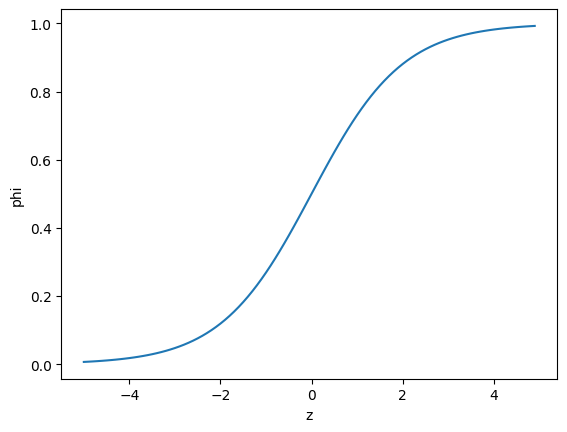

In [24]:
import numpy as np
import matplotlib.pyplot as plt
z = np.arange(-5, 5, 0.1) #z위치마다 시그모이드 함수 계산
phi = 1 / (1 + np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

이진 분류의 경우, 시그모이드 함수 출력이 0.5보다 작으면 음성 클래스, 크면 양성 클래스

넘파이 배열은 True, False 값을 전달하여 행 선택 가능-> 불리언 인덱싱

In [25]:
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [26]:
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

In [27]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

LogisticRegression()

In [28]:
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [29]:
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [30]:
print(lr.classes_) #앞에가 음성, 뒤에가 양성

['Bream' 'Smelt']


In [31]:
print(lr.coef_, lr.intercept_)

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]


In [36]:
decisions = lr.decision_function(train_bream_smelt[:5]) #z값 계산
#양성 클래스에 대한 z값 반환
print(decisions)

[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [35]:
from scipy.special import expit #np.exp보다 간단하게 확률 얻기 -> expit
print(expit(decisions))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


이진 분류의 경우, predict_proba() 메서드는 음성클래스와 양성클래스에 대한 확률 출력
decision_function() 메서드는 양성클래스에 대한 z값을 계산

로지스틱 다중 분류

릿지 회귀와 같이 계수의 제곱을 규제. 매개변쉬 C가 작을 수록 규제가 커짐

In [37]:
lr = LogisticRegression(C=20, max_iter=1000) #반복횟수 1000
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.9327731092436975
0.925


In [38]:
print(lr.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']


In [39]:
proba = lr.predict_proba(test_scaled[:5]) #클래스별 확률 값
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [40]:
print(lr.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [41]:
print(lr.coef_.shape, lr.intercept_.shape)

(7, 5) (7,)


다중 분류는 소프트맥스 함수를 사용-> 7개의 z 값을 확률로 변환

시그모이드는 하나의 선형 방정식 출력값을 0-1사이로 압축
소프트맥스는 여러개의 방정식 출력값을 0-1사이로 압축하고
전체 합이 1이 되도록-> 규화된 지수 함수

In [42]:
decision = lr.decision_function(test_scaled[:5]) #z값 구하기
print(np.round(decision, decimals=2))

[[ -6.51   1.04   5.17  -2.76   3.34   0.35  -0.63]
 [-10.88   1.94   4.78  -2.42   2.99   7.84  -4.25]
 [ -4.34  -6.24   3.17   6.48   2.36   2.43  -3.87]
 [ -0.69   0.45   2.64  -1.21   3.26  -5.7    1.26]
 [ -6.4   -1.99   5.82  -0.13   3.5   -0.09  -0.7 ]]


In [46]:
from scipy.special import softmax #소프트맥스로 확률 구하기
proba = softmax(decision, axis=1) #축을 1로 지정하여 각 행에 대해 계산
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


결론: 로지스틱회귀는 회귀가 아니라 분류 모델이다. 선형 방정식 사용. 0-1로 값 압축.
방정식의 출력값을 시그모이드 함수에 통과시켜 0-1값으로 만듦-> 양성클래스 확률

확인문제

*   1번 문제: 정답 2번
*   2번 문제: 정답 1번
*   3번 문제: 정답 3번






# 4-2 확률적 경사 하강법

점진적으로 데이터를 학습시킨다. 경사를 따라 내려간다. 훈련 세트에서 랜덤하게 하나의 샘플 고름

랜덤하게 하나의 샘플을 사용해 가파른 경사를 조금 내려가고, 다음 또 선택해서 내려가고..
전체 샘플을 모두 사용할때까지 계속=> 에포크(epoch).

일반적으로 경사 하강법은 수십, 수백 번 이상의 에포크를 수행

미니배치 경사 하강법: 여러개의 샘플을 선택해서 경사를 따라 내려간다

배치 경사 하강법: 극단적으로 한번 경사로를 따라 이동하기 위해 전체 샘플을 사용

신경망 알고리즘에서 주로 사용

손실 함수: 머신러닝 알고리즘이 얼마나 엉터리인지 측정하는 기준. 작을수록 좋다. 미분 가능해야함

로지스틱 손실 함수: -(예측 x 타깃) = 이진 크로스엔트로피 손실 함수

이진분류는 로지스틱 손실 함수/ 다중분류는 크로스엔트로피 손실함수

In [48]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')

In [49]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]. to_numpy()
fish_target = fish['Species'].to_numpy()

In [50]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state = 42
)

In [52]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) #표준화 전처리
train_sclaed = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [53]:
from sklearn.linear_model import SGDClassifier

In [56]:
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [57]:
sc.partial_fit(train_scaled, train_target) #모델을 이어서 훈련할 때 partial_fit
print(sc.score(train_scaled, train_target)) #호출할 때마다 1 에포크씩 이어서 훈련
print(sc.score(test_scaled, test_target))

0.7983193277310925
0.775


### 에포크와 과대/과소 적합

에포크 횟수가 적으면 모델이 훈련 세트 덜 학습해서 과소적합
많으면 과대적합

In [60]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42)
train_score = [] #에포크마다 훈련셋, 테스트셋 점수 기록하려고 리스트 준비
test_score = []
classes = np.unique(train_target) #train_target에 있는 7개의 생선 목록

In [62]:
for _ in range(0,300):
  sc.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sc.score(train_scaled, train_target))
  test_score.append(sc.score(test_scaled, test_target))

<function matplotlib.pyplot.show(close=None, block=None)>

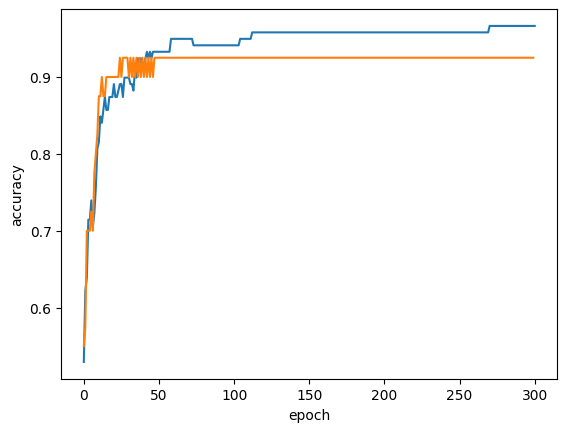

In [63]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show

100번째 에포크가 적절해보임

In [66]:
sc = SGDClassifier(loss = 'log_loss', max_iter=100, tol=None, random_state=42)
#자동으로 멈추지 말고 에포크 100번 해라
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


일정 에포크 동안 성능이 향상되지 않으면 자동으로 멈춤. tol에서 향상될 최솟값 지정

SGDRegressor는 확률적 경사 하강법을 사용한 회귀 알고리즘

loss 매개변수의 기본값은 'hinge': 힌지 손실은 서포트 벡터 머신이라 불리는 것의 손실 함수

In [67]:
sc = SGDClassifier(loss= 'hinge', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925


결론 정리: 실시간 학습을 위해 확률적 경사 하강법 사용(점진적 학습)-> 후에 신경망 관련됨

확인 문제

*   1번 문제: 정답 ? 모르겠음
*   2번 문제: 정답 3번

